#### Part A - Data Loading and Preprocessing with Scikit-learn

##### Task 1 - Load and Understand the Dataset

In [2]:
import pandas as pd

df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [8]:
df.shape

(119390, 32)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [6]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [10]:
# 2. Target distribution
print("\nClass Distribution of 'is_canceled':")
print(df["is_canceled"].value_counts(normalize=True) * 100)

y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])


Class Distribution of 'is_canceled':
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


In [11]:
# 3. Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


Numerical columns (19): ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical columns (12): ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


##### Task 2: Missing Values, Leakage, and Outliers

In [12]:
# 1. Check missing values
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print("Missing values summary:\n", missing_summary[missing_summary['Missing Count'] > 0])

Missing values summary:
           Missing Count  Missing Percentage (%)
children              4                0.003350
country             488                0.408744
agent             16340               13.686238
company          112593               94.306893


In [13]:
# 2. Drop high missingness & target leakage columns
# 'company' has ~94% missing values; 'reservation_status' & 'reservation_status_date' cause data leakage
drop_cols = ['company', 'reservation_status', 'reservation_status_date']
df_clean = df.drop(columns=[col for col in drop_cols if col in df.columns]).copy()

In [14]:
# 3. Clean extreme / impossible outliers
initial_rows = len(df_clean)

# Keep bookings with at least one guest and valid ADR
df_clean = df_clean[~((df_clean['adults'] == 0) & (df_clean['children'] == 0) & (df_clean['babies'] == 0))]
df_clean = df_clean[(df_clean['adr'] >= 0) & (df_clean['adr'] < 5000)]

# IQR-based removal on 'adr' and 'lead_time' for extreme values
for col in ['adr', 'lead_time']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    # Use 3 * IQR for extreme outlier threshold
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

rows_removed = initial_rows - len(df_clean)
print(f"\nExtreme outliers removed: {rows_removed} rows (Remaining: {len(df_clean)})")

# Re-define X and y after cleaning
y = df_clean["is_canceled"]
X = df_clean.drop(columns=["is_canceled"])

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()


Extreme outliers removed: 678 rows (Remaining: 118712)


In [19]:
df_clean.to_csv("hotel_bookings_cleaned.csv")

##### Task 3: Create Two Preprocessing Pipelines

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Categorical pipeline (common to both)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Pipeline A Numerical Transformer (StandardScaler)
num_transformer_A = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

# Pipeline B Numerical Transformer (MinMaxScaler)
num_transformer_B = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

# Preprocessor A
preprocessor_A = ColumnTransformer(transformers=[
    ('num', num_transformer_A, numerical_cols),
    ('cat', cat_transformer, categorical_cols)
])

# Preprocessor B
preprocessor_B = ColumnTransformer(transformers=[
    ('num', num_transformer_B, numerical_cols),
    ('cat', cat_transformer, categorical_cols)
])

##### Task 4: Train Two Classification Models

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Define the 4 model pipelines
models = {
    "Logistic Regression (StandardScaler)": Pipeline(steps=[
        ('preprocessor', preprocessor_A),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Logistic Regression (MinMaxScaler)": Pipeline(steps=[
        ('preprocessor', preprocessor_B),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Decision Tree (StandardScaler)": Pipeline(steps=[
        ('preprocessor', preprocessor_A),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    "Decision Tree (MinMaxScaler)": Pipeline(steps=[
        ('preprocessor', preprocessor_B),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ])
}

# Train all 4 pipelines
trained_models = {}
for name, pipe in models.items():
    print(f"Training: {name}...")
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

Training: Logistic Regression (StandardScaler)...
Training: Logistic Regression (MinMaxScaler)...
Training: Decision Tree (StandardScaler)...
Training: Decision Tree (MinMaxScaler)...


##### Task 5: Evaluate and Compare the Four Results


--- Model Comparison Table ---


,Model & Pipeline,Train Accuracy,Test Accuracy,Overfitting Gap (Train - Test),Precision,Recall,F1-Score
0,Logistic Regression (StandardScaler),0.8187,0.8152,0.0035,0.8038,0.6622,0.7262
1,Logistic Regression (MinMaxScaler),0.8148,0.8110,0.0038,0.8003,0.6519,0.7186
2,Decision Tree (StandardScaler),0.9960,0.8604,0.1357,0.8053,0.8212,0.8132
3,Decision Tree (MinMaxScaler),0.9960,0.8605,0.1356,0.8054,0.8214,0.8133


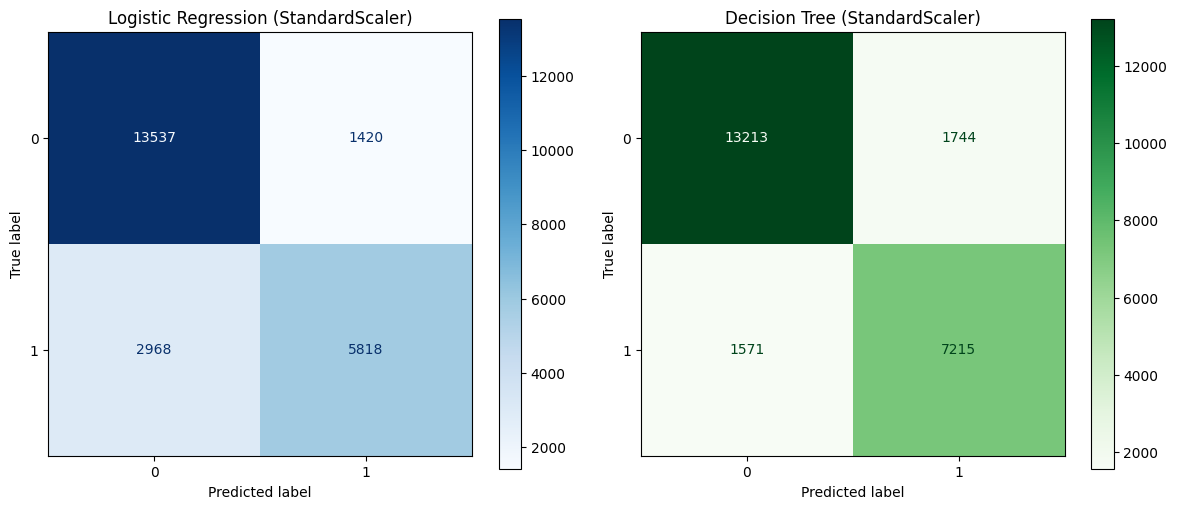

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)

results = []

for name, model in trained_models.items():
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    
    results.append({
        "Model & Pipeline": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Overfitting Gap (Train - Test)": round(train_acc - test_acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

results_df = pd.DataFrame(results)
print("\n--- Model Comparison Table ---")
display(results_df)

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Best LR: StandardScaler
ConfusionMatrixDisplay.from_estimator(
    trained_models["Logistic Regression (StandardScaler)"], 
    X_test, y_test, ax=axes[0], cmap="Blues"
)
axes[0].set_title("Logistic Regression (StandardScaler)")

# Best DT: Decision Tree (StandardScaler)
ConfusionMatrixDisplay.from_estimator(
    trained_models["Decision Tree (StandardScaler)"], 
    X_test, y_test, ax=axes[1], cmap="Greens"
)
axes[1].set_title("Decision Tree (StandardScaler)")

plt.tight_layout()
plt.show()

##### Task 6: Final Observations

- Best Overall Result: The Decision Tree is the most accurate model, achieving the highest test accuracy (86.05%) and F1-score (0.8133). It captures the patterns in the booking data significantly better than Logistic Regression.

- Logistic Regression Scaling Impact: StandardScaler provides slightly better results for Logistic Regression. It leads to higher test accuracy (81.52% vs. 81.10%) and a better F1-score (0.7262 vs. 0.7186) compared to MinMaxScaler.

- Decision Tree Scaling Impact: Scaling makes no meaningful difference for the Decision Tree. The performance metrics between StandardScaler and MinMaxScaler differ by only 0.0001. This aligns with machine learning theory, as tree-based models split nodes based on order and thresholds, rendering them invariant to feature scaling.

- Overfitting Analysis: The Decision Tree is heavily overfitting. It practically memorized the training set (99.6% accuracy) but suffered a severe 13.5% performance drop on the test set. Conversely, Logistic Regression generalizes excellently, maintaining a negligible gap (~0.3%) between training and testing performance, indicating stable but simpler decision boundaries.